In [ ]:
import pandas as pd

data = [
    # Family, Attn, Dataset, F1, Precision, Recall, AUPRC

    ["Fourier", "Attn", "SWaT", 0.9316, 0.9631, 0.9021, 0.9672],
    ["Fourier", "Attn", "MSL",  0.8477, 0.8017, 0.8993, 0.8533],
    ["Fourier", "NoAttn", "SWaT", 0.9200, 0.9833, 0.8643, 0.9456],
    ["Fourier", "NoAttn", "MSL",  0.8720, 0.9266, 0.8236, 0.9049],

    ["RBF", "Attn", "SWaT", 0.9260, 0.9665, 0.8887, 0.9470],
    ["RBF", "Attn", "MSL",  0.8684, 0.9007, 0.8382, 0.9059],
    ["RBF", "NoAttn", "SWaT", 0.9445, 0.9782, 0.9131, 0.9308],
    ["RBF", "NoAttn", "MSL",  0.9445, 0.9782, 0.9131, 0.9308],

    ["Wavelet", "Attn", "SWaT", 0.9508, 0.9352, 0.9669, 0.9810],
    ["Wavelet", "Attn", "MSL",  0.9242, 0.9158, 0.9327, 0.9047],
    ["Wavelet", "NoAttn", "SWaT", 0.9063, 0.8681, 0.9480, 0.9704],
    ["Wavelet", "NoAttn", "MSL",  0.7246, 0.7393, 0.7104, 0.6606],
]

df = pd.DataFrame(data, columns=[
    "Family", "Attention", "Dataset",
    "F1", "Precision", "Recall", "AUPRC"
])

df

,Family,Attention,Dataset,F1,Precision,Recall,AUPRC
0,Fourier,Attn,SWaT,0.9316,0.9631,0.9021,0.9672
1,Fourier,Attn,MSL,0.8477,0.8017,0.8993,0.8533
2,Fourier,NoAttn,SWaT,0.9200,0.9833,0.8643,0.9456
3,Fourier,NoAttn,MSL,0.8720,0.9266,0.8236,0.9049
4,RBF,Attn,SWaT,0.9260,0.9665,0.8887,0.9470
5,RBF,Attn,MSL,0.8684,0.9007,0.8382,0.9059
6,RBF,NoAttn,SWaT,0.9445,0.9782,0.9131,0.9308
7,RBF,NoAttn,MSL,0.9445,0.9782,0.9131,0.9308
8,Wavelet,Attn,SWaT,0.9508,0.9352,0.9669,0.9810
9,Wavelet,Attn,MSL,0.9242,0.9158,0.9327,0.9047


In [2]:
import pandas as pd
import numpy as np

# -----------------------------
# KAN family selection results
# Attention + DeepSVDD variants only
# -----------------------------

data = [
    # Family, Dataset, F1, Precision, Recall, AUPRC
    ["Fourier", "SWaT", 0.9316, 0.9631, 0.9021, 0.9672],
    ["Fourier", "MSL",  0.8477, 0.8017, 0.8993, 0.8533],

    ["RBF", "SWaT", 0.9260, 0.9665, 0.8887, 0.9470],
    ["RBF", "MSL",  0.8684, 0.9007, 0.8382, 0.9059],

    ["Wavelet", "SWaT", 0.9508, 0.9352, 0.9669, 0.9810],
    ["Wavelet", "MSL",  0.9242, 0.9158, 0.9327, 0.9047],
]

df_family = pd.DataFrame(data, columns=[
    "KAN Family", "Dataset", "F1", "Precision", "Recall", "AUPRC"
])

# -----------------------------
# Add rankings per dataset
# -----------------------------
df_family["F1 Rank"] = (
    df_family.groupby("Dataset")["F1"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

df_family["AUPRC Rank"] = (
    df_family.groupby("Dataset")["AUPRC"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

# Mark best F1 per dataset
df_family["Best F1?"] = np.where(df_family["F1 Rank"] == 1, "Best", "")

# -----------------------------
# Convert metrics to percentages
# -----------------------------
metric_cols = ["F1", "Precision", "Recall", "AUPRC"]

df_display = df_family.copy()
for col in metric_cols:
    df_display[col] = (df_display[col] * 100).round(2)

df_display = df_display.sort_values(
    ["Dataset", "F1 Rank"],
    ascending=[True, True]
).reset_index(drop=True)

df_display

,KAN Family,Dataset,F1,Precision,Recall,AUPRC,F1 Rank,AUPRC Rank,Best F1?
0,Wavelet,MSL,92.42,91.58,93.27,90.47,1,2,Best
1,RBF,MSL,86.84,90.07,83.82,90.59,2,1,
2,Fourier,MSL,84.77,80.17,89.93,85.33,3,3,
3,Wavelet,SWaT,95.08,93.52,96.69,98.10,1,1,Best
4,Fourier,SWaT,93.16,96.31,90.21,96.72,2,2,
5,RBF,SWaT,92.60,96.65,88.87,94.70,3,3,


In [3]:
# -----------------------------
# Average performance across datasets
# -----------------------------

summary = (
    df_family
    .groupby("KAN Family")[["F1", "Precision", "Recall", "AUPRC"]]
    .mean()
    .reset_index()
)

summary["Average Rank"] = (
    summary["F1"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

summary_display = summary.copy()
for col in ["F1", "Precision", "Recall", "AUPRC"]:
    summary_display[col] = (summary_display[col] * 100).round(2)

summary_display = summary_display.sort_values("Average Rank").reset_index(drop=True)

summary_display

,KAN Family,F1,Precision,Recall,AUPRC,Average Rank
0,Wavelet,93.75,92.55,94.98,94.28,1
1,RBF,89.72,93.36,86.34,92.64,2
2,Fourier,88.96,88.24,90.07,91.02,3


In [ ]:
df[df["Dataset"] == "SWaT"].sort_values("PointF1", ascending=False)

,Family,Attention,Dataset,PointF1,EventF1,DelayF1,AUPRC
8,Wavelet,Attn,SWaT,0.9508,0.1143,0.8647,0.9810
6,RBF,NoAttn,SWaT,0.9445,0.0879,0.3286,0.9308
0,Fourier,Attn,SWaT,0.9316,0.0926,0.8353,0.9672
4,RBF,Attn,SWaT,0.9260,0.0822,0.7388,0.9470
2,Fourier,NoAttn,SWaT,0.9200,0.1224,0.2957,0.9456
10,Wavelet,NoAttn,SWaT,0.9063,0.2000,0.6850,0.9704


In [ ]:
df[df["Dataset"] == "MSL"].sort_values("PointF1", ascending=False)

,Family,Attention,Dataset,PointF1,EventF1,DelayF1,AUPRC
7,RBF,NoAttn,MSL,0.9445,0.0879,0.3286,0.9308
9,Wavelet,Attn,MSL,0.9242,0.1818,0.3568,0.9047
3,Fourier,NoAttn,MSL,0.8720,0.2000,0.3661,0.9049
5,RBF,Attn,MSL,0.8684,0.2326,0.3600,0.9059
1,Fourier,Attn,MSL,0.8477,0.2353,0.2958,0.8533
11,Wavelet,NoAttn,MSL,0.7246,0.2308,0.4157,0.6606


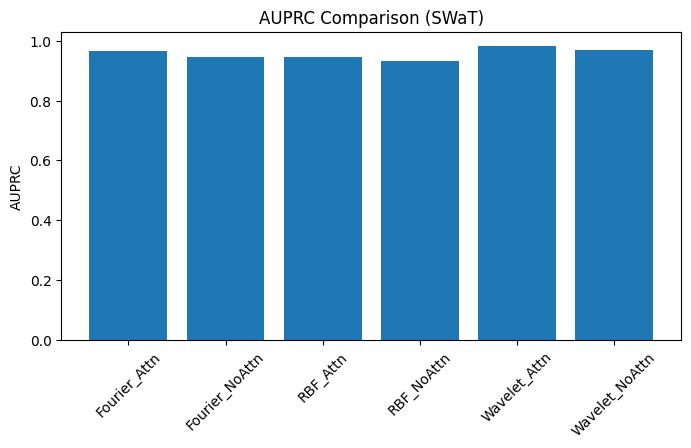

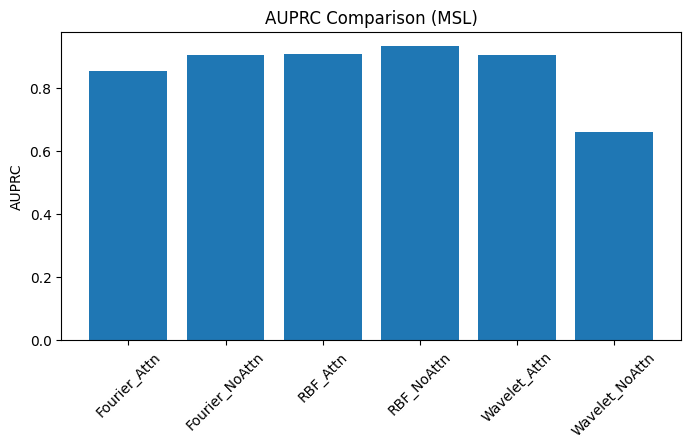

In [ ]:
for dataset in ["SWaT", "MSL"]:
    sub = df[df["Dataset"] == dataset]

    plt.figure(figsize=(8,4))
    plt.bar(sub["Family"] + "_" + sub["Attention"], sub["AUPRC"])
    plt.title(f"AUPRC Comparison ({dataset})")
    plt.xticks(rotation=45)
    plt.ylabel("AUPRC")
    plt.show()

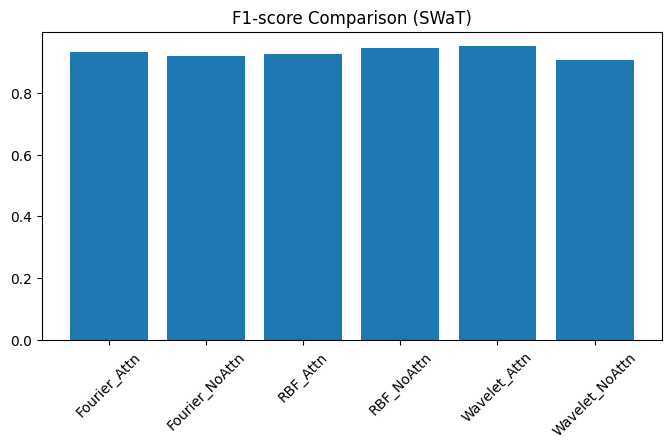

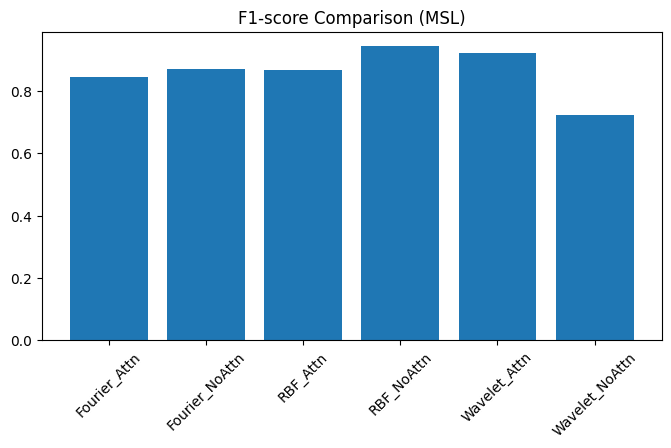

In [ ]:
for dataset in ["SWaT", "MSL"]:
    sub = df[df["Dataset"] == dataset]

    plt.figure(figsize=(8,4))
    plt.bar(sub["Family"] + "_" + sub["Attention"], sub["F1"])
    plt.title(f"F1-score Comparison ({dataset})")
    plt.xticks(rotation=45)
    plt.show()

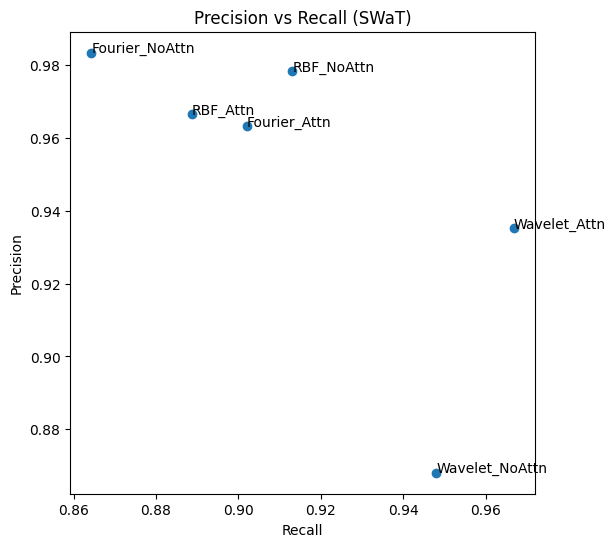

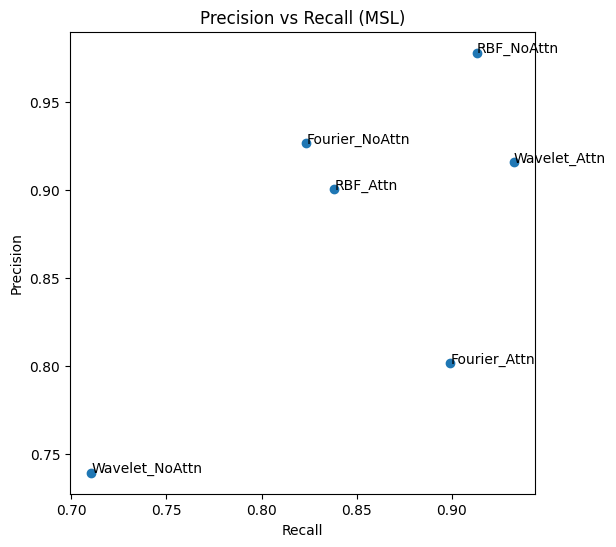

In [ ]:
for dataset in ["SWaT", "MSL"]:
    sub = df[df["Dataset"] == dataset]

    plt.figure(figsize=(6,6))
    plt.scatter(sub["Recall"], sub["Precision"])

    for i, row in sub.iterrows():
        plt.text(row["Recall"], row["Precision"], row["Family"]+"_"+row["Attention"])

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision vs Recall ({dataset})")
    plt.show()

In [ ]:
attn_effect = []

for fam in ["Fourier", "RBF", "Wavelet"]:
    for dataset in ["SWaT", "MSL"]:
        attn = df[(df.Family==fam)&(df.Attention=="Attn")&(df.Dataset==dataset)].iloc[0]
        no = df[(df.Family==fam)&(df.Attention=="NoAttn")&(df.Dataset==dataset)].iloc[0]

        attn_effect.append([
            fam, dataset,
            attn["PointF1"] - no["PointF1"],
            attn["AUPRC"] - no["AUPRC"]
        ])

attn_df = pd.DataFrame(attn_effect, columns=["Family", "Dataset", "ΔF1", "ΔAUPRC"])
attn_df

,Family,Dataset,ΔF1,ΔAUPRC
0,Fourier,SWaT,0.0116,0.0216
1,Fourier,MSL,-0.0243,-0.0516
2,RBF,SWaT,-0.0185,0.0162
3,RBF,MSL,-0.0761,-0.0249
4,Wavelet,SWaT,0.0445,0.0106
5,Wavelet,MSL,0.1996,0.2441
